# 모델·데이터·평가 보고서 — 4조

LoL 경기는 언제 승부가 결정되는가 — 인게임 시점별 경기 데이터 기반 승패 예측 및 핵심 승리요인 분석

| | 내용 |
|---|---|
| **1** | 팀에서 채택한 모델 |
| **2** | 학습/테스트 데이터 뷰와 분할 상태 |
| **3** | 테스트 데이터 평가 결과 |
| **4** | 혼동행렬 (confusion matrix) |

위에서부터 실행하면 모든 수치가 재현됩니다. (Python 3.11 · scikit-learn 1.9.0 · 시드 42)

In [1]:
# ── 준비: 경로 맞추기 · 라이브러리 불러오기 · 한글 글꼴 ──────────────
# 이 노트북은 어느 폴더에서 열어도 돌아가야 합니다.
# 그래서 위쪽 폴더를 최대 6단계 거슬러 올라가며 "artifacts 폴더와 predict.py 가
# 같이 있는 곳" = 프로젝트 루트를 찾아 이동합니다.
%matplotlib inline
import os, json, sys, warnings
from pathlib import Path

_p = Path.cwd()
for _ in range(6):
    if (_p / "artifacts").is_dir() and (_p / "predict.py").is_file():
        os.chdir(_p)
        break
    _p = _p.parent
sys.path.insert(0, str(_p))            # lolwin 패키지를 찾을 수 있게

import joblib, numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")      # sklearn 버전 안내문 숨김 (결과에는 영향 없음)

# 피처 목록과 데이터 적재는 lolwin 라이브러리에서 가져옵니다.
# 피처 정의는 lolwin/features.py 한 곳에만 있습니다 — 여기가 어긋나면 모든 게 어긋나므로.
from lolwin.features import DIFF13
from lolwin.data import load as load_data

# 그림에 한글이 깨지지 않도록, 설치된 한글 글꼴을 순서대로 찾아 씁니다
for _f in ("Malgun Gothic", "AppleGothic", "NanumGothic"):
    if any(_f == f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.dpi"] = 110

# 그림에서 계속 쓸 색 — 파랑=블루 팀/채택, 빨강=레드 팀/경고
BLUE, RED, GRAY = "#2f6fe4", "#c0392b", "#9aa5b1"
print("준비 완료 —", os.getcwd())

준비 완료 — C:\AI 캠퍼스 MLOps양성과정\ML\ML실습\4조_LoL 인게임 시점별 경기 데이터 기반 승패 예측 및 핵심 승리요인 분석


---
## 1. 팀에서 채택한 모델

**로지스틱 회귀** (`StandardScaler` + `LogisticRegression`을 Pipeline 하나로 저장)

10분 시점의 상황 13개를 넣으면 **파란 팀이 이길 확률**을 돌려주고, 0.5 이상이면 승리로 판정합니다.
계산은 두 단계입니다 — ① 각 지표에 가중치를 곱해 더하고 ② 그 값을 0~1 확률로 바꿉니다.
**이 가중치가 곧 해석**이라, 어떤 지표가 승패에 얼마나 작용했는지 그대로 읽을 수 있습니다.

### 왜 이 모델인가 — 후보 8개를 같은 조건에서 비교 (5조각 교차검증, 시드 42)

| 모델 | 교차검증 정확도 | 연습−검증 격차 | 판정 |
|---|---|---|---|
| **로지스틱 회귀** | **0.7280 ± 0.0163** | **+0.0039** | ✅ 채택 |
| 랜덤포레스트 | 0.7248 | +0.2752 (연습 1.0000) | ❌ 통째로 외움 |
| GaussianNB | 0.7238 | +0.0015 | 2위 이하 |
| SVM (RBF) | 0.7223 | +0.0391 | ❌ 기준 초과 |
| 결정트리 · KNN · HistGB | 0.7140~0.7180 | 최대 +0.1387 | ❌ / 하위 |
| 찍기 (기준선) | 0.5009 | — | 비교 출발선 |

**성능이 모델 복잡도의 역순이었습니다.** 랜덤포레스트는 연습 점수가 만점(1.0000)인데
처음 보는 데이터에서 0.7248로 떨어집니다. 외운 것이지 배운 게 아닙니다.

로지스틱을 고른 이유는 ① 점수 1위 ② 외우지 않음 ③ **가중치로 "왜"를 설명할 수 있음** 입니다.

**튜닝은 하지 않았습니다.** 골드차 1개만 넣어도 0.7313, 골드차+경험치차 2개면 0.7328로
전체와 거의 같습니다. 정보가 두 지표에 몰려 있어 조정해도 짜낼 것이 없습니다.
판정 기준값도 0.40~0.60을 훑어본 결과 평평해서 **기본값 0.5**를 그대로 씁니다.

Pipeline 구성: StandardScaler → LogisticRegression
입력 지표 13개 · 시점 10분 · 시드 42
scikit-learn 1.9.0 · 절편 -0.0043


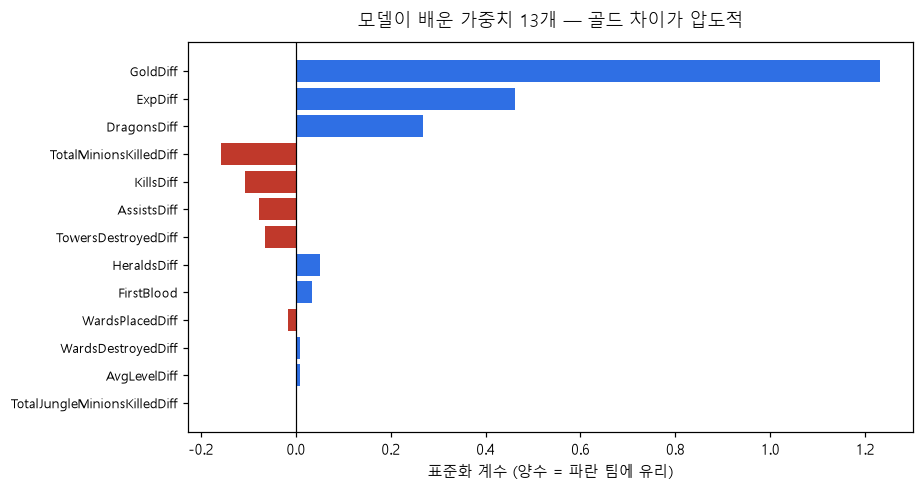

In [2]:
# ── 채택 모델 열어보기: 안에 무엇이 들어 있나 ────────────────────────
# 학습 때 저장한 파이프라인(표준화 + 로지스틱 회귀)을 통째로 불러옵니다.
# 통째로 저장했기 때문에 예측할 때 표준화를 빠뜨릴 수가 없습니다.
model = joblib.load("artifacts/model.joblib")
schema = json.load(open("artifacts/schema.json", encoding="utf-8"))   # 입력 규격·성능 기록
lr = model.named_steps["model"]                                       # 로지스틱 회귀 부분

print("Pipeline 구성:", " → ".join(type(s).__name__ for s in model.named_steps.values()))
print(f"입력 지표 {len(schema['features'])}개 · 시점 {schema['time_point_min']}분 · 시드 {schema['seed']}")
print(f"scikit-learn {schema['sklearn_version']} · 절편 {lr.intercept_[0]:.4f}")

# 가중치(표준화 계수)를 절대값 큰 순으로 — 이 숫자가 곧 "왜"입니다
coef = pd.Series(lr.coef_[0], index=DIFF13).sort_values(key=abs, ascending=False)

# 그림: 가중치 13개 전부. 오른쪽(파랑)=블루에 유리, 왼쪽(빨강)=불리
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ordered = coef[::-1]                                # 큰 것이 위로 오게 뒤집기
ax.barh(range(len(ordered)), ordered.values,
        color=[BLUE if v > 0 else RED for v in ordered.values])
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(ordered.index, fontsize=8.5)
ax.axvline(0, color="black", lw=0.8)                # 0 기준선
ax.set_xlabel("표준화 계수 (양수 = 파란 팀에 유리)")
ax.set_title("모델이 배운 가중치 13개 — 골드 차이가 압도적", fontsize=12, pad=10)
plt.show()

> 킬 차이의 계수가 음수인데 "킬하면 진다"는 뜻이 아닙니다. 킬을 하면 돈을 받으므로
> 킬의 가치가 이미 골드 차이에 들어가 있어(상관 +0.92), 골드를 아는 모델에게 킬은 더 보탤 정보가 없다는 뜻입니다.

**왜 로지스틱인가** — 후보 8종을 같은 조건(5조각 교차검증·시드 42)에서 비교해
① 점수 1위(0.7280) ② 연습−검증 격차 +0.0039(외우지 않음) ③ 가중치로 "왜"를 설명 가능, 세 가지로 채택했습니다.
랜덤포레스트는 연습 만점(1.0000)이었지만 검증 0.7248로 무너져 탈락(과적합).

**외우지 않은 후보 중 로지스틱 다음이던 나이브베이즈**는 끝까지 학습해 확인했습니다 — 아래 실행 결과가 탈락 근거입니다.

,정확도,AUC,Brier(낮을수록 좋음),극단 확신 비중
로지스틱 (채택),0.7394,0.8150,0.1756,4.9%
나이브베이즈,0.7313,0.8096,0.2179,63.6%


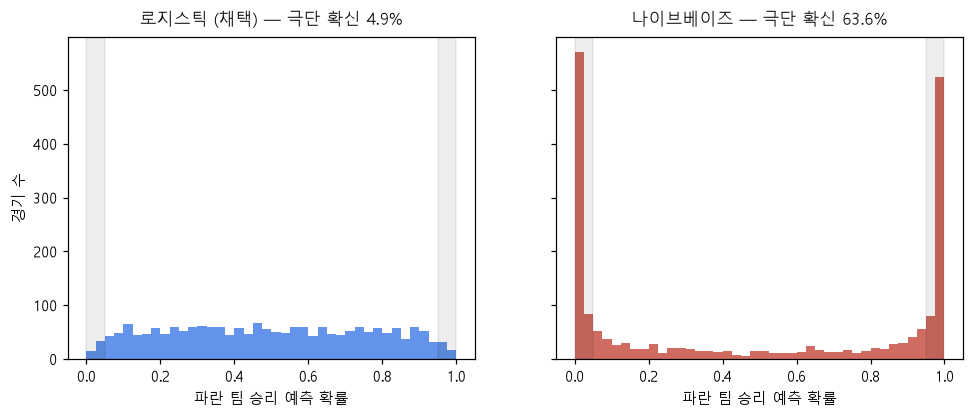

In [3]:
# ── 차점자 검증: 나이브베이즈를 같은 데이터로 끝까지 학습해 비교 ─────
# "왜 로지스틱이어야 했나"에 답하려면 차점자가 왜 안 됐는지 보여줘야 합니다.
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss

X_tr, y_tr, X_te, y_te, meta = load_data()          # 저장된 분할 그대로 (아래 2장에서 검증)
nb_model = Pipeline([("scaler", StandardScaler()),   # 로지스틱과 같은 전처리 조건
                     ("model", GaussianNB())]).fit(X_tr, y_tr)

# "극단 확신" = 확률이 5% 미만이거나 95% 초과 — 모델이 아주 강하게 단정한 경기
EXTREME_LO, EXTREME_HI = 0.05, 0.95

rows = []
for name, m in [("로지스틱 (채택)", model), ("나이브베이즈", nb_model)]:
    p = m.predict_proba(X_te)[:, 1]                  # 파란 팀 승리 확률
    rows.append({"정확도": f"{accuracy_score(y_te, (p >= 0.5).astype(int)):.4f}",
                 "AUC": f"{roc_auc_score(y_te, p):.4f}",
                 "Brier(낮을수록 좋음)": f"{brier_score_loss(y_te, p):.4f}",
                 "극단 확신 비중": f"{((p < EXTREME_LO) | (p > EXTREME_HI)).mean():.1%}"})
display(pd.DataFrame(rows, index=["로지스틱 (채택)", "나이브베이즈"]))

# 그림: 두 모델이 내놓는 확률의 분포. 회색 띠 = 극단 확신 구간
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)
bins = np.linspace(0, 1, 41)
for ax, (name, m) in zip(axes, [("로지스틱 (채택)", model), ("나이브베이즈", nb_model)]):
    p = m.predict_proba(X_te)[:, 1]
    ext = ((p < EXTREME_LO) | (p > EXTREME_HI)).mean()
    ax.hist(p, bins=bins, color=BLUE if "로지스틱" in name else RED, alpha=0.75)
    ax.axvspan(0, EXTREME_LO, color="black", alpha=0.07)
    ax.axvspan(EXTREME_HI, 1, color="black", alpha=0.07)
    ax.set_title(f"{name} — 극단 확신 {ext:.1%}", fontsize=11, pad=8)
    ax.set_xlabel("파란 팀 승리 예측 확률")
axes[0].set_ylabel("경기 수")
plt.show()

**그래프 읽는 법** — 왼쪽(로지스틱)은 확률이 0~1에 고르게 퍼져 있는데,
오른쪽(나이브베이즈)은 **양끝 회색 띠에 쌓여 있습니다.** 경기 3판 중 2판에 "95% 이상/5% 이하" 확신을 거는 것입니다 — 팽팽한 접전에도요.

지표끼리 상관 0.9로 얽혀 있는데 NB는 독립이라 가정하고 곱해 나가니, **같은 증거(성장 격차)를 여섯 번 세는 셈**이라 그렇습니다.
정확도는 비슷해도 우리 서비스는 확률을 화면에 그대로 보여주므로 **나이브베이즈는 탈락**입니다. (개념 → `STUDY.md` 15번)

---
## 2. 학습/테스트 데이터 뷰와 분할 상태

### 원천 데이터

Kaggle 다이아 랭크 10분 스냅샷 **9,879행 × 40컬럼** (한 행 = 경기 한 판), 팀 MariaDB `lol_matches_10min`에 적재.
**결측 0건 · 중복 0건 · 승패 50.10 : 49.90** (거의 반반이라 정확도를 1순위 지표로 쓰는 것이 정당합니다).

### 뷰 구성

피처 계산식은 **SQL 뷰 한 곳에만** 두고 파이썬은 읽기만 합니다 (`db/create_ml_views.sql`).

```
lol_matches_10min ─┬─ ml_split (분할 고정)
                   └─→ v_base ─→ v_diff13_all ─┬─ v_diff13_train (7,903행)
                                                └─ v_diff13_test  (1,976행)
```

| 뷰 | 지표 수 | 용도 |
|---|---|---|
| **`v_diff13_train` / `_test`** | **13** | **채택** — 학습·평가에 사용 |
| `v_clean27_train` / `_test` | 27 | 중복만 제거한 대조군 |
| `v_gold2_train` / `_test` | 2 | 최소 구성 기준선 |
| `v_cluster5_train` / `_test` | 5 | 경기 유형 분류 전용 (비지도, 예측에 미사용) |

뷰가 4종이라고 모델이 4개인 게 아니라, **하나의 모델에 넣을 재료 묶음**을 바꿔 비교한 것입니다.
학습에는 `_train`만 쓰고 `_test`는 최종 채점에서 한 번만 엽니다.

**지표 13개는 "파란 팀 − 빨간 팀" 차이값**입니다. 원본 38개 중 11개가 중복(거울 컬럼·상수배·합계 컬럼)이라
지우고 차이값으로 합쳤더니, 지표는 절반인데 정확도는 올랐습니다(0.7334 → 0.7369).

In [4]:
# ── 분할 상태 표 + 진단 4항목 + 모델 이력 ───────────────────────────
TOTAL_GAMES = 9_879        # 원본 CSV 행 수 (Kaggle 다이아 10분 스냅샷 · data/README.md)
STRATIFY_LIMIT = 0.01      # 층화 오차 허용선 — 두 쪽 승패 비율 차이가 이보다 작아야 함

display(pd.DataFrame({
    "경기 수": [f"{len(y_tr):,}", f"{len(y_te):,}", f"{len(y_tr) + len(y_te):,}"],
    "비율": ["80%", "20%", "100%"],
    "승리 비율": [f"{y_tr.mean():.4f}", f"{y_te.mean():.4f}",
                  f"{(y_tr.sum() + y_te.sum()) / (len(y_tr) + len(y_te)):.4f}"],
}, index=["학습(train)", "시험(test)", "전체"]))

print(f"데이터 출처: {meta['data_source']}   (DB 접속 정보가 없으면 같은 계산식의 CSV 로 자동 전환)")
print()

# 분할 진단 — 하나라도 어긋나면 이후 점수는 못 믿습니다
overlap = len(set(X_tr.index) & set(X_te.index))      # 같은 경기가 양쪽에 있나
missing = TOTAL_GAMES - len(y_tr) - len(y_te)          # 합쳐서 원본과 같나
strat_gap = abs(y_tr.mean() - y_te.mean())             # 두 쪽 승패 비율 차이
print("분할 진단 4항목")
print(f"  ① 학습·시험 겹치는 경기 : {overlap}건  ({'통과' if overlap == 0 else '실패!'})")
print(f"  ② 빠진 행               : {missing}건  ({'통과' if missing == 0 else '실패!'})")
print(f"  ③ 층화 오차              : {strat_gap:.4f}  ({'통과' if strat_gap < STRATIFY_LIMIT else '실패!'}, 기준 {STRATIFY_LIMIT})")
print(f"  ④ 분할 고정              : data/splits/*.csv 저장 · gameId 정렬 · 시드 {schema['seed']}")
print()

# 모델 이력(provenance) — 이 모델이 어떤 데이터·코드에서 나왔는지 schema.json 에 기록돼 있음
prov = schema.get("provenance", {})
print("모델 이력")
print(f"  데이터 지문 {prov.get('data_hash')} · 분할 지문 {prov.get('split_hash')} · git {prov.get('git_commit')}")

,경기 수,비율,승리 비율
학습(train),"7,903",80%,0.4991
시험(test),"1,976",20%,0.4990
전체,"9,879",100%,0.4990


데이터 출처: csv:fallback   (DB 접속 정보가 없으면 같은 계산식의 CSV 로 자동 전환)

분할 진단 4항목
  ① 학습·시험 겹치는 경기 : 0건  (통과)
  ② 빠진 행               : 0건  (통과)
  ③ 층화 오차              : 0.0001  (통과, 기준 0.01)
  ④ 분할 고정              : data/splits/*.csv 저장 · gameId 정렬 · 시드 42

모델 이력
  데이터 지문 82b2e2327909 · 분할 지문 570ca964/9a14d580 · git b1f2709


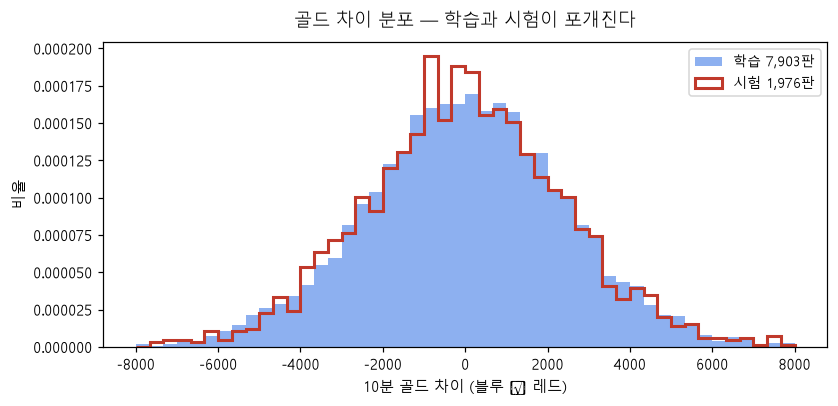

In [5]:
# ── 그림: 학습/시험의 주력 지표 분포가 같은 모양인가 ─────────────────
# 시험셋에만 쉬운(또는 어려운) 경기가 몰려 있으면 채점이 공정하지 않습니다.
# 골드 차이(가장 강한 지표)의 분포를 두 쪽에 겹쳐 그려 확인합니다.
fig, ax = plt.subplots(figsize=(8.5, 3.6))
bins = np.linspace(-8000, 8000, 49)
ax.hist(X_tr["GoldDiff"], bins=bins, density=True, color=BLUE, alpha=0.55,
        label=f"학습 {len(y_tr):,}판")
ax.hist(X_te["GoldDiff"], bins=bins, density=True, histtype="step", lw=2,
        color=RED, label=f"시험 {len(y_te):,}판")
ax.set_xlabel("10분 골드 차이 (블루 − 레드)")
ax.set_ylabel("비율")
ax.legend(fontsize=9)
ax.set_title("골드 차이 분포 — 학습과 시험이 포개진다", fontsize=12, pad=10)
plt.show()

**그래프 읽는 법** — 파란 막대(학습)와 빨간 선(시험)이 거의 포개집니다.
**시험셋만 유난히 쉽거나 어려운 경기로 채워지지 않았다**는 뜻입니다.
층화 분할이 승패 비율뿐 아니라 지표 분포까지 비슷하게 나눠 준 것을 눈으로 확인했습니다.

**분할이 전처리보다 먼저입니다.** 전처리를 먼저 하면 시험 데이터의 통계가 학습에 새어 들어가
점수가 가짜로 오릅니다(누수). 오류가 나지 않아 모르고 지나가기 가장 쉬운 실수입니다.
시험셋은 모델·지표 선택에 일절 쓰지 않고 최종 채점에만 사용했습니다.

---
## 3. 테스트 데이터 평가 결과

봉인해 둔 **테스트 1,976판**(학습에 한 번도 쓰지 않은 데이터)으로 채점합니다.

In [6]:
from sklearn.metrics import (accuracy_score, brier_score_loss, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve)

proba = model.predict_proba(X_te)[:, 1]     # 파란 팀 승리 확률
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()

acc, prec = accuracy_score(y_te, pred), precision_score(y_te, pred)
rec, f1 = recall_score(y_te, pred), f1_score(y_te, pred)
auc, brier = roc_auc_score(y_te, proba), brier_score_loss(y_te, proba)
baseline = max(y_te.mean(), 1 - y_te.mean())

display(pd.DataFrame({
    "값": [f"{acc:.4f}", f"{prec:.4f}", f"{rec:.4f}", f"{tn/(tn+fp):.4f}",
           f"{f1:.4f}", f"{auc:.4f}", f"{brier:.4f}", f"{baseline:.4f}", f"+{(acc-baseline)*100:.1f}%p"],
    "의미": ["100판 중 74판 적중", "승리라 한 것 중 실제 승리", "실제 승리 중 잡아낸 비율",
             "실제 패배 중 잡아낸 비율", "정밀도·재현율의 균형", "순위 매기는 능력 (0.5=찍기)",
             "확률 자체의 정확도 (낮을수록 좋음)", "다수 클래스로만 찍었을 때", "찍기보다 24판 더 맞힘"],
}, index=["정확도", "정밀도", "재현율", "특이도", "F1", "AUC", "Brier", "찍기 기준선", "개선폭"]))

print(classification_report(y_te, pred, target_names=["패배(0)", "승리(1)"], digits=4))

,값,의미
정확도,0.7394,100판 중 74판 적중
정밀도,0.7456,승리라 한 것 중 실제 승리
재현율,0.7252,실제 승리 중 잡아낸 비율
특이도,0.7535,실제 패배 중 잡아낸 비율
F1,0.7352,정밀도·재현율의 균형
AUC,0.8150,순위 매기는 능력 (0.5=찍기)
Brier,0.1756,확률 자체의 정확도 (낮을수록 좋음)
찍기 기준선,0.5010,다수 클래스로만 찍었을 때
개선폭,+23.8%p,찍기보다 24판 더 맞힘


              precision    recall  f1-score   support

       패배(0)     0.7335    0.7535    0.7434       990
       승리(1)     0.7456    0.7252    0.7352       986

    accuracy                         0.7394      1976
   macro avg     0.7395    0.7393    0.7393      1976
weighted avg     0.7395    0.7394    0.7393      1976



**이 점수가 운이 아닌 근거**

| 검증 | 결과 | 기준 | 판정 |
|---|---|---|---|
| 5조각 교차검증 | 0.7315 ± 0.0153 | 편차 0.02 미만 | ✅ |
| 연습−검증 격차 | +0.0022 | 0.03 미만 | ✅ 외우지 않음 |
| 분할을 바꿔 10번 재학습 | **0.7366 ± 0.0081** | 10회 모두 0.70 이상 | ✅ 10/10 |

위 0.7394는 특정 분할 하나의 값이라, 반복 평균 0.7366 ± 0.0081과 함께 보는 것이 정직합니다.

**언제 틀리나** — 정확도는 골드 차이에 따라 크게 다릅니다.

,경기수,정확도,비중
구간,,,
"접전 (1,000 미만)",680,0.6147,34.4%
"우세 (1,000~2,500)",721,0.7406,36.5%
"크게 우세 (2,500~4,200)",404,0.8589,20.4%
"사실상 결정 (4,200 이상)",171,0.9474,8.7%


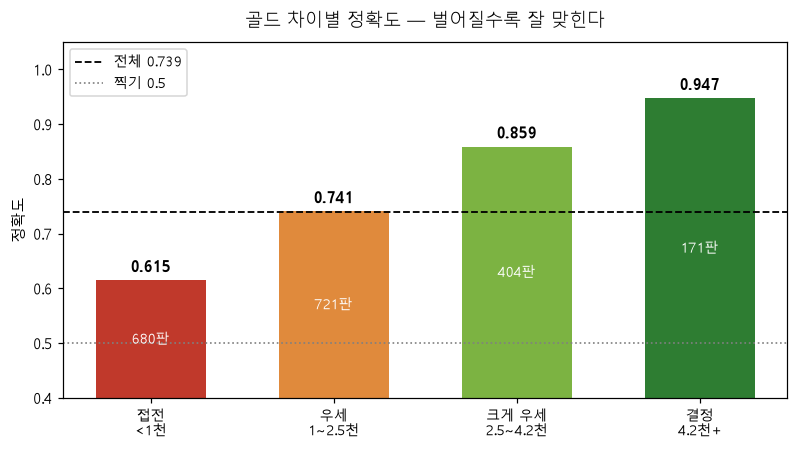

In [7]:
# ── 구간별 정확도: 전체 평균 하나로 뭉뚱그리면 안 보이는 것 ──────────
# 10분 골드 차이의 크기(절대값)로 경기를 네 구간으로 나눠 따로 채점합니다.
# 구간 경계는 EDA 에서 정한 값 — 1천 미만이 "접전", 4.2천 이상이 "사실상 결정"
GOLD_BINS = [0, 1000, 2500, 4200, np.inf]
BIN_NAMES = ["접전 (1,000 미만)", "우세 (1,000~2,500)",
             "크게 우세 (2,500~4,200)", "사실상 결정 (4,200 이상)"]

err = pd.DataFrame({"골드차": X_te["GoldDiff"].abs().values,
                    "맞힘": (pred == y_te.values).astype(int)})
err["구간"] = pd.cut(err["골드차"], bins=GOLD_BINS, labels=BIN_NAMES, right=False)
seg = err.groupby("구간", observed=True).agg(경기수=("맞힘", "size"), 정확도=("맞힘", "mean"))
seg["비중"] = seg["경기수"] / seg["경기수"].sum()
display(seg.style.format({"정확도": "{:.4f}", "비중": "{:.1%}"}))

# 그림: 구간별 정확도. 검은 점선 = 전체 평균, 회색 점선 = 찍기
NL = chr(10)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
colors = [RED, "#e08a3c", "#7cb342", "#2e7d32"]     # 못 맞힘(빨강) → 잘 맞힘(초록)
ax.bar(range(len(seg)), seg["정확도"], color=colors, width=0.6)
for i, (v, n) in enumerate(zip(seg["정확도"], seg["경기수"])):
    ax.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=10.5, fontweight="bold")
    ax.text(i, 0.4 + (v - 0.4) / 2, f"{n}판", ha="center", va="center", fontsize=9, color="white")
ax.axhline(acc, color="black", ls="--", lw=1.2, label=f"전체 {acc:.3f}")
ax.axhline(0.5, color="gray", ls=":", lw=1.1, label="찍기 0.5")
ax.set_xticks(range(len(seg)))
ax.set_xticklabels(["접전" + NL + "<1천", "우세" + NL + "1~2.5천",
                    "크게 우세" + NL + "2.5~4.2천", "결정" + NL + "4.2천+"], fontsize=9)
ax.set_ylim(0.4, 1.05)
ax.set_ylabel("정확도")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("골드 차이별 정확도 — 벌어질수록 잘 맞힌다", fontsize=12, pad=10)
plt.show()

접전을 못 맞히는 건 모델이 부족해서가 아니라 **그 시점 정보에 아직 승패의 단서가 없기 때문**입니다.
같은 경기를 15분 시점에서 보면 접전 구간만 정확도가 7.8%p 오르고, 이미 벌어진 경기는 전혀 오르지 않습니다(±0.0%p).

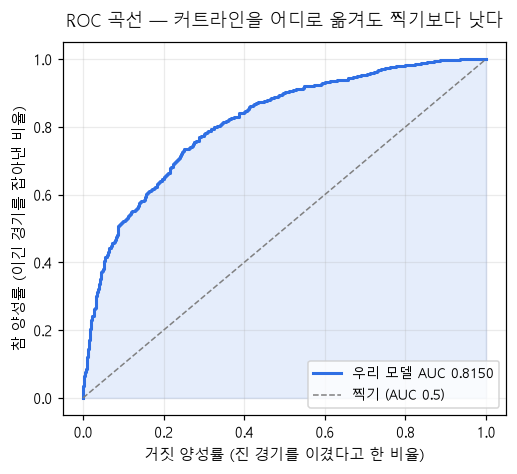

In [8]:
# ── ROC 곡선: "0.5에서 자른다"는 기준을 바꿔도 성능이 유지되나 ────────
# 정확도는 커트라인 0.5 하나에서만 잰 점수입니다. ROC 는 커트라인을
# 0부터 1까지 전부 옮겨가며 재고, 곡선 아래 넓이가 AUC 입니다.
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_te, proba)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.plot(fpr, tpr, lw=2, color=BLUE, label=f"우리 모델 AUC {auc:.4f}")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="찍기 (AUC 0.5)")
ax.fill_between(fpr, tpr, alpha=0.12, color=BLUE)
ax.set_xlabel("거짓 양성률 (진 경기를 이겼다고 한 비율)")
ax.set_ylabel("참 양성률 (이긴 경기를 잡아낸 비율)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.25)
ax.set_title("ROC 곡선 — 커트라인을 어디로 옮겨도 찍기보다 낫다", fontsize=11.5, pad=10)
plt.show()

**그래프 읽는 법** — 회색 점선(찍기)에서 왼쪽 위로 멀수록 좋습니다. AUC 0.8150은
"이긴 경기와 진 경기를 하나씩 뽑았을 때, **이긴 쪽에 더 높은 확률을 줄 가능성이 81.5%**"라는 뜻입니다.
커트라인을 어디로 잡아도 성능이 유지되므로, 기본값 0.5를 그대로 쓴 근거가 됩니다.

---
## 4. 혼동행렬 (Confusion Matrix)

"무엇을 무엇으로 예측했는지"를 2×2로 보여줍니다. 정확도 하나로는 안 보이는 **틀리는 방향**이 드러납니다.

,패배 예측 (0),승리 예측 (1),합계
실제 패배 (0),746,244,990
실제 승리 (1),271,715,986
합계,1017,959,1976


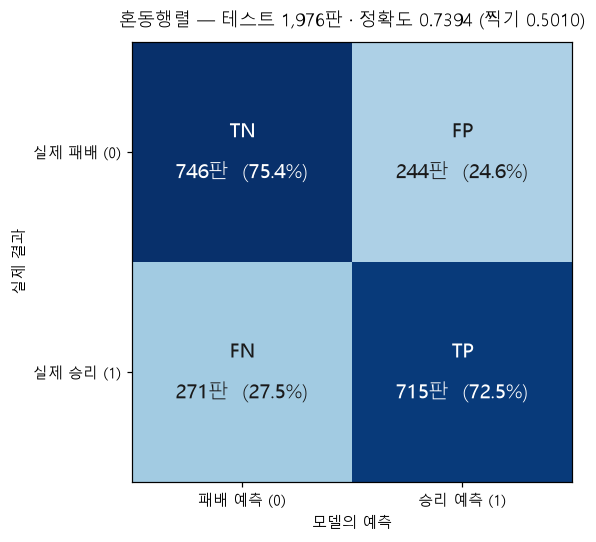

In [9]:
# ── 혼동행렬: 무엇을 무엇으로 예측했는지 2×2 로 ──────────────────────
# 표로 먼저 (합계 포함), 그다음 같은 내용을 그림으로.
cm_table = pd.DataFrame(cm, index=["실제 패배 (0)", "실제 승리 (1)"],
                        columns=["패배 예측 (0)", "승리 예측 (1)"])
cm_table["합계"] = cm_table.sum(axis=1)
cm_table.loc["합계"] = cm_table.sum()
display(cm_table)

# 그림: 칸마다 이름표(TN/FP/FN/TP) + 경기 수 + 행 기준 비율
NL = chr(10)
tags = [["TN", "FP"], ["FN", "TP"]]
cmn = cm / cm.sum(axis=1, keepdims=True)     # 행 기준 비율 (실제 패배 중 몇 %, 실제 승리 중 몇 %)
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
for i in range(2):
    for j in range(2):
        ax.text(j, i, tags[i][j] + NL + NL + f"{cm[i, j]:,}판  ({cmn[i, j]:.1%})",
                ha="center", va="center", fontsize=13,
                color="white" if cm[i, j] > cm.max() * 0.6 else "#1a1a1a")
ax.set_xticks([0, 1]); ax.set_xticklabels(["패배 예측 (0)", "승리 예측 (1)"], fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(["실제 패배 (0)", "실제 승리 (1)"], fontsize=10)
ax.set_xlabel("모델의 예측"); ax.set_ylabel("실제 결과")
ax.set_title(f"혼동행렬 — 테스트 {len(y_te):,}판 · 정확도 {acc:.4f} (찍기 {baseline:.4f})",
             fontsize=12, pad=10)
plt.show()

**읽는 법** — 대각선(TN·TP)이 맞힌 것, 나머지가 틀린 것입니다.

**틀린 방향이 244 대 271로 거의 같습니다.** 한쪽으로 치우쳐 틀리지 않는다는 뜻이고,
승패 어느 쪽도 편들지 않는 모델이라는 근거입니다. 비율로 보면 실제 패배의 75.4%,
실제 승리의 72.5%를 맞혀 두 값이 비슷합니다.

---
## 5. 보충 — 골드를 빼고 다시 학습하면 (페이즈 2 요약)

위 가중치 그림에서 골드가 +1.23으로 압도적이었고, 킬·미니언 등은 음수였습니다.
골드가 다른 지표의 몫까지 가져간 것인지 확인하려고 **골드를 빼고 같은 조건으로 다시 학습**했습니다.

,홀드아웃 정확도,킬 차이 계수,1위 요인
전체 13개,0.7394,-0.107,GoldDiff
골드 제외 12개,0.7373,+0.508,ExpDiff


정확도 차이: +0.0020  ← 가장 강한 지표를 뺐는데 이만큼밖에 안 떨어짐


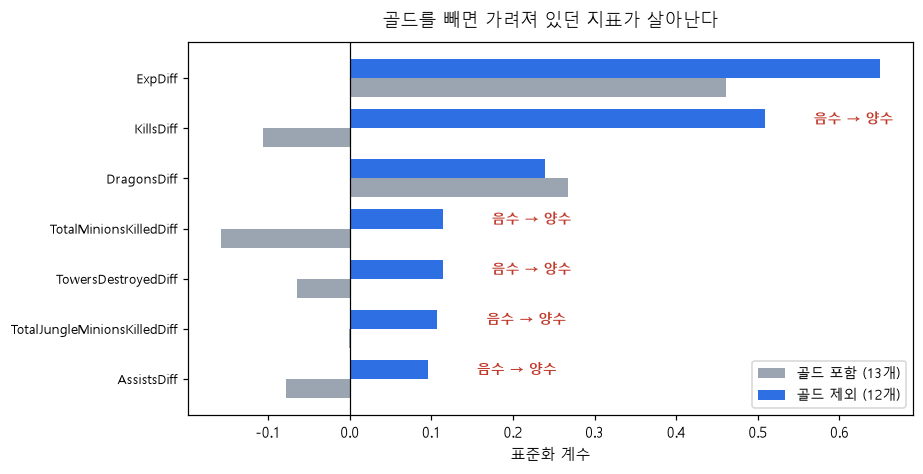

In [10]:
# ── 페이즈 2 재현: 골드를 빼고 같은 조건으로 다시 학습 ────────────────
# 골드 포함 13개 vs 골드 제외 12개 — 분할·전처리·시드 전부 동일
from sklearn.linear_model import LogisticRegression

no_gold = [f for f in DIFF13 if f != "GoldDiff"]          # 골드만 뺀 12개
m12 = Pipeline([("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=1000, random_state=schema["seed"]))])
m12.fit(X_tr[no_gold], y_tr)

acc12 = accuracy_score(y_te, m12.predict(X_te[no_gold]))
coef12 = pd.Series(m12.named_steps["model"].coef_[0], index=no_gold)

display(pd.DataFrame({
    "홀드아웃 정확도": [f"{acc:.4f}", f"{acc12:.4f}"],
    "킬 차이 계수": [f"{coef['KillsDiff']:+.3f}", f"{coef12['KillsDiff']:+.3f}"],
    "1위 요인": ["GoldDiff", coef12.abs().idxmax()],
}, index=["전체 13개", "골드 제외 12개"]))
print(f"정확도 차이: {acc - acc12:+.4f}  ← 가장 강한 지표를 뺐는데 이만큼밖에 안 떨어짐")

# 그림: 골드에 눌려 음수였던 지표들이 골드를 빼면 살아나는가
SHOW = coef12.abs().sort_values(ascending=False).head(7).index[::-1]   # 위쪽이 큰 값
y_pos, w = np.arange(len(SHOW)), 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.barh(y_pos - w / 2, [coef.get(k, 0) for k in SHOW], w, color=GRAY, label="골드 포함 (13개)")
ax.barh(y_pos + w / 2, [coef12.get(k, 0) for k in SHOW], w, color=BLUE, label="골드 제외 (12개)")
for i, k in enumerate(SHOW):                       # 음수 → 양수로 뒤집힌 지표 표시
    if coef.get(k, 0) < 0 < coef12.get(k, 0):
        ax.annotate("음수 → 양수", xy=(coef12[k], i + w / 2),
                    xytext=(coef12[k] + 0.06, i + w / 2), fontsize=9,
                    color=RED, fontweight="bold", va="center")
ax.set_yticks(y_pos); ax.set_yticklabels(SHOW, fontsize=8.5)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("표준화 계수")
ax.legend(fontsize=9, loc="lower right")
ax.set_title("골드를 빼면 가려져 있던 지표가 살아난다", fontsize=12, pad=10)
plt.show()

**그래프 읽는 법** — 회색(골드 포함)에서 왼쪽(음수)이던 킬·미니언·어시스트·타워가
파랑(골드 제외)에서는 전부 오른쪽(양수)으로 넘어왔습니다. 킬은 **−0.107 → +0.508**입니다.

**킬이 승패와 무관했던 게 아니라 골드가 킬의 몫까지 가져갔던 것**입니다 (다중공선성 — `STUDY.md` 10번).
그런데 정확도는 0.002밖에 안 떨어졌습니다 — 다른 지표들이 이미 같은 정보를 담고 있어서입니다.
그래서 최종 모델은 13개를 유지하되, 화면의 승리요인은 계수 대신 **효과크기 순위**로 보여줍니다.

### 정리

| 항목 | 결과 |
|---|---|
| 채택 모델 | 로지스틱 회귀 (8종 중 1위, 과적합 없음, 설명 가능) |
| 데이터·분할 | 9,879판 → 학습 7,903 / 시험 1,976 (층화·시드 42·겹침 0) |
| 뷰 | `v_diff13_train` / `v_diff13_test` (지표 13개) |
| **정확도** | **0.7394** (찍기 0.5010 대비 +23.8%p) · 반복 0.7366 ± 0.0081 |
| F1 / AUC / Brier | 0.7352 / 0.8150 / 0.1756 |
| **혼동행렬** | **TN 746 · FP 244 / FN 271 · TP 715** |
| 한계 | 접전 구간(34%) 0.615 — 10분 정보 자체의 한계 |

재현: `python src/finalize_model.py` · `python src/repeat_check.py`